<a href="https://colab.research.google.com/github/eduardozurek/ia/blob/main/_006_reduccion_de_dimensiones/001_PCA_smartwatch_smartphone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Análisis de Componentes Principales**

Se usarán los datos del acelerómetro del reloj ubicados en datos_watch_accel.pkl

La activación de Google Drive se hace manualmente usando los enlaces del lado izquierdo


In [2]:
try:
    import numpy as np
except ImportError:
    %pip install numpy
    import numpy as np
try:
    import scipy as sp
except ImportError:
    %pip install scipy
    import scipy as sp
try:
    import pandas as pd
except ImportError:
    %pip install pandas
    import pandas as pd
try:
    import matplotlib.pyplot as plt
except ImportError:
    %pip install matplotlib
    import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ImportError:
    %pip install seaborn
    import seaborn as sns
try:
    import sklearn as skl
except ImportError:
    %pip install scikit-learn
    import sklearn as skl

In [ ]:
# Esta celda debe ejecutarse solamente una vez
!wget https://raw.githubusercontent.com/eduardozurek/ia/main/_005_clustering/WISDM/data_1603_accel_phone.arff
!wget https://raw.githubusercontent.com/eduardozurek/ia/main/_005_clustering/WISDM/data_1603_accel_watch.arff
!wget https://raw.githubusercontent.com/eduardozurek/ia/main/_005_clustering/WISDM/data_1603_gyro_phone.arff
!wget https://raw.githubusercontent.com/eduardozurek/ia/main/_005_clustering/WISDM/data_1603_gyro_watch.arff

In [4]:
data_accel_watch, meta = sp.io.arff.loadarff('data_1603_accel_watch.arff')
df_accel_watch = pd.DataFrame(data_accel_watch)
df_accel_watch.columns = df_accel_watch.columns.str.replace('"', '', regex=False)
df_accel_watch['ACTIVITY'] = df_accel_watch['ACTIVITY'].str.decode('utf-8')
df_accel_watch['class'] = df_accel_watch['class'].str.decode('utf-8')
df_accel_watch.head()

,ACTIVITY,X0,X1,X2,X3,X4,X5,X6,X7,X8,...,ZMFCC11,ZMFCC12,XYCOS,XZCOS,YZCOS,XYCOR,XZCOR,YZCOR,RESULTANT,class
0,A,0.0,0.0,0.0,0.0,0.02,0.195,0.275,0.240,0.205,...,0.482083,0.475888,-0.424800,-0.540664,0.742245,0.180966,0.028993,0.653510,13.6987,1603
1,A,0.0,0.0,0.0,0.0,0.00,0.190,0.465,0.310,0.035,...,0.408916,0.403662,-0.543209,-0.657680,0.661040,0.223324,-0.043878,0.455660,12.3760,1603
2,A,0.0,0.0,0.0,0.0,0.00,0.100,0.610,0.270,0.020,...,0.362887,0.358224,-0.526723,-0.542331,0.768224,0.268513,0.066037,0.664313,12.4360,1603
3,A,0.0,0.0,0.0,0.0,0.00,0.135,0.585,0.240,0.035,...,0.358655,0.354046,-0.562874,-0.573174,0.750614,0.270042,-0.030761,0.619433,12.2830,1603
4,A,0.0,0.0,0.0,0.0,0.00,0.115,0.555,0.265,0.065,...,0.372644,0.367856,-0.455862,-0.561776,0.766964,0.382146,0.091794,0.672474,12.5075,1603


In [5]:
# preparamos los datos para el clustering
#d_accel = datos_accel.loc[datos_accel["class"].isin(["1603"])]
d_accel = df_accel_watch
print(d_accel.shape)

(324, 93)


In [6]:
import numpy as np
ground_truth = d_accel["ACTIVITY"].values
lookupTable, ground_truth = np.unique(ground_truth, return_inverse=True)
xyzbins = ["X0" ,"X1" ,"X2" ,"X3" ,"X4" ,"X5" ,"X6" ,"X7" ,"X8" ,"X9" ,"Y0" ,"Y1" ,"Y2" ,"Y3" ,"Y4" ,"Y5" ,
            "Y6" ,"Y7" ,"Y8" ,"Y9" ,"Z0" ,"Z1" ,"Z2" ,"Z3" ,"Z4" ,"Z5" ,"Z6" ,"Z7" ,"Z8" ,"Z9"]
absoldev = ["XABSOLDEV" ,"YABSOLDEV" ,"ZABSOLDEV"]
X = d_accel[xyzbins].values

In [7]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2,whiten=False).fit(X)
print(pca.explained_variance_ratio_)
print(pca.singular_values_)
transformados = pca.fit_transform(X)
print(transformados.shape)

[0.30223413 0.25656003]
[8.79633536 8.10446822]
(324, 2)


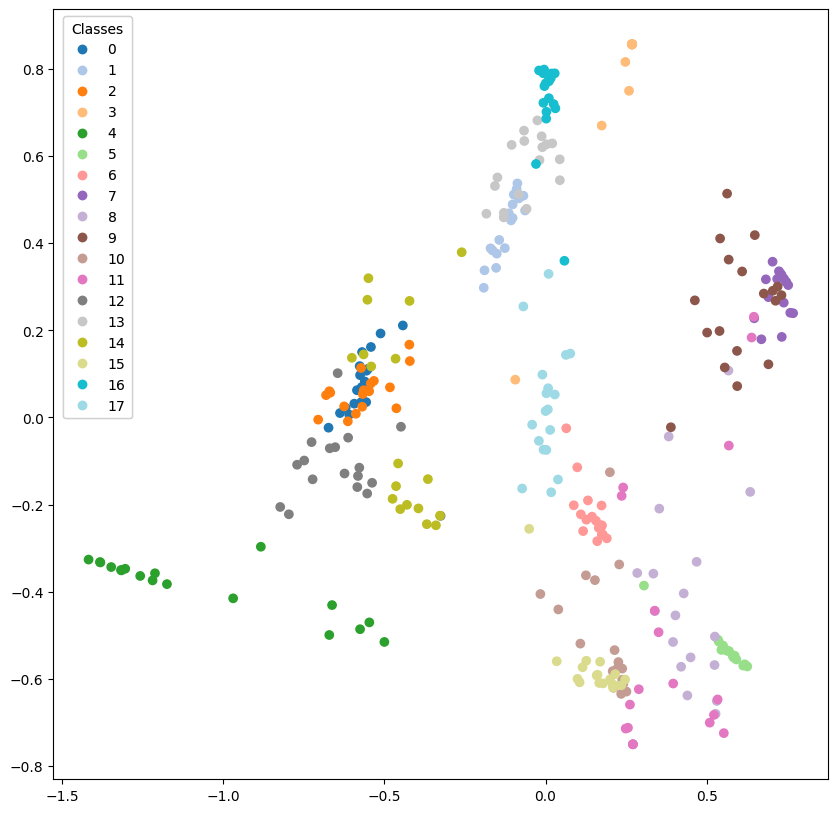

In [35]:
import matplotlib.pyplot as plt
x = transformados[:,0]
y = transformados[:,1]
c = ground_truth
fig, ax = plt.subplots(figsize=[10,10])
scatter = ax.scatter(x, y, c=c, cmap="tab20")
legend1 = ax.legend(*scatter.legend_elements(num=len(np.unique(ground_truth))),
                    bbox_to_anchor=(0.11, 1.0), loc='upper right',
                    title="Classes")
ax.add_artist(legend1)
plt.show()